# Airbnb NYC Data Analysis: Pricing & Customer Insights

#### 🔹 Problem Statement 

> In a highly competitive short-term rental market, understanding pricing dynamics and customer preferences is critical for maximizing revenue and occupancy. This project analyzes the Airbnb NYC 2019 dataset to identify key factors influencing listing prices, room type demand, host performance, and availability patterns.

> Through exploratory data analysis and visualization, the project uncovers actionable insights that can help hosts optimize pricing strategies, improve listing performance, and support data-driven decision-making in the hospitality domain.


---

## 📊 Dataset Description

> The dataset used in this project is the **Airbnb NYC 2019 dataset**, which contains information about Airbnb listings in New York City. It includes details about pricing, location, room types, host information, availability, and customer reviews.

* **Total Records:** ~48,000 listings
* **Key Features:**

  * `neighbourhood_group` – Area of the listing (Manhattan, Brooklyn, etc.)
  * `price` – Price per night
  * `room_type` – Type of room (Entire home, private room, shared room)
  * `minimum_nights` – Minimum nights required for booking
  * `number_of_reviews` – Total number of reviews
  * `reviews_per_month` – Review frequency
  * `availability_365` – Availability of listing in a year
  * `host_name` – Name of the host

> This dataset helps in analyzing pricing strategies, customer preferences, and host performance.

---

## Tools & Technologies Used

* **Python** – Programming language
* **Pandas** – Data manipulation and analysis
* **NumPy** – Numerical computations
* **Matplotlib & Seaborn** – Data visualization
* **Plotly** – Interactive visualizations
* **Jupyter Notebook** – Development environment



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import plotly.express as px

In [2]:
import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')
sns.set_palette("pastel")

#####  Importing Dataset

In [3]:
data = pd.read_csv('AB_NYC_2019.csv')

In [4]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [5]:
data.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### 1. `Pricing Trends Across Neighborhoods`

  

In [7]:
avg_price = data.groupby('neighbourhood_group')['price'].mean()
avg_price

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

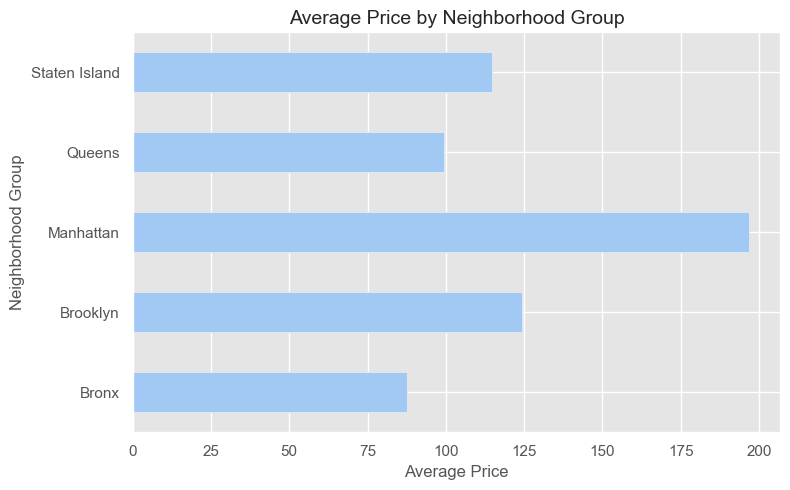

In [8]:
avg_price.plot(kind='barh', figsize=(8,5))

plt.title("Average Price by Neighborhood Group", fontsize=14)
plt.xlabel("Average Price")
plt.ylabel("Neighborhood Group")

plt.tight_layout()
plt.show()

 >Listings in Manhattan have the highest average prices compared to other neighborhood groups,   indicating premium demand and central location advantage. Brooklyn follows as the second-highest, while other areas show relatively lower pricing.

### `2. Most Preferred Room Type`

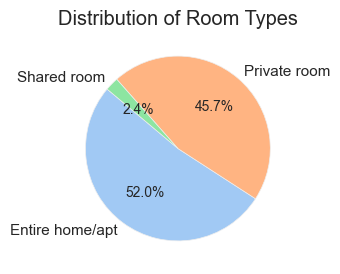

In [9]:
data['room_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(3,3),
    startangle=140
)

plt.title("Distribution of Room Types")
plt.ylabel("")
plt.show()

>The most commonly available room type is Entire home/apartment, followed by private rooms. This suggests that customers prefer privacy and complete space over shared accommodations.

### `3. Minimum Stay Requirements`

<Axes: ylabel='neighbourhood_group'>

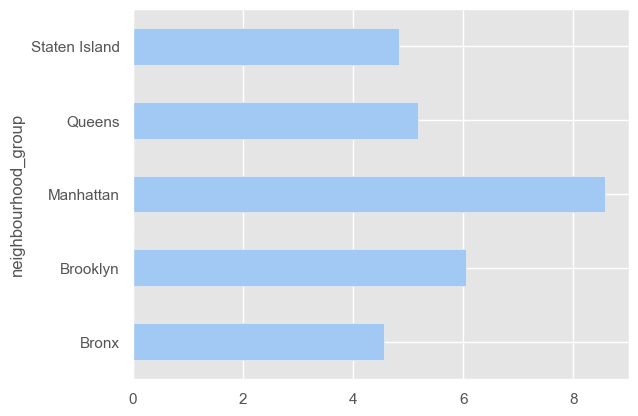

In [10]:
data.groupby('neighbourhood_group')['minimum_nights'].mean().plot(kind = 'barh',stacked = True)

> The average minimum nights requirement varies across neighborhoods, with some areas enforcing longer stays. This may indicate hosts targeting long-term guests to ensure stable income.

### `4. Host Distribution`

In [11]:
data['host_name'].unique().shape[0]

11453

>The dataset contains a large number of unique hosts, indicating a highly competitive and fragmented marketplace with many individual property owners.

### `5. Top Hosts by Listings`

In [12]:
# top 5 hosts
data['host_name'].value_counts(ascending = False).head().reset_index()

,host_name,count
0,Michael,417
1,David,403
2,Sonder (NYC),327
3,John,294
4,Alex,279


In [13]:
# top 5 hosts based on neighbourhood_group
top_hosts = data.groupby(['neighbourhood_group', 'host_name']).size().reset_index(name='listing_count')
top_hosts = top_hosts.sort_values(['neighbourhood_group', 'listing_count'], ascending=[True, False])
top_hosts = top_hosts.groupby('neighbourhood_group').head(5)

top_hosts

,neighbourhood_group,host_name,listing_count
612,Bronx,Vie,13
56,Bronx,Armando,10
97,Bronx,Carol,9
465,Bronx,Orit,9
111,Bronx,Charles,8
4544,Brooklyn,Michael,159
1942,Brooklyn,David,142
5649,Brooklyn,Sarah,133
809,Brooklyn,Alex,122
4507,Brooklyn,Melissa,105


> A small group of hosts manages multiple listings, suggesting the presence of professional hosts or property managers dominating certain areas.

### `6. Highest Priced Neighborhood`

In [14]:
 data.groupby('neighbourhood_group')['price'].mean().sort_values(ascending = False).reset_index().head(1)

,neighbourhood_group,price
0,Manhattan,196.875814


> Manhattan emerges as the neighborhood with the highest average listing price, reinforcing its position as a premium market with high demand.

### `7. Price vs Reviews Relationship`

In [15]:
correlation = data['price'].corr(data['reviews_per_month'])
correlation

-0.030608348567533115

> There is a weak correlation between price and reviews per month, indicating that higher-priced listings do not necessarily receive more reviews or bookings.

### `8. Listings with No Reviews`

In [16]:
data[data['reviews_per_month'] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


A significant number of listings have zero reviews, which may indicate:

  * New listings

   * Low demand

 * Poor visibility or pricing strategy

### `9. Room Type Distribution by Area`

In [17]:
distribution = data.groupby(['neighbourhood_group','room_type']).size().unstack()
distribution

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,379,652,60
Brooklyn,9559,10132,413
Manhattan,13199,7982,480
Queens,2096,3372,198
Staten Island,176,188,9


> Entire homes dominate across most neighborhood groups, but private rooms are also widely available, especially in budget-friendly areas.

<Axes: xlabel='neighbourhood_group'>

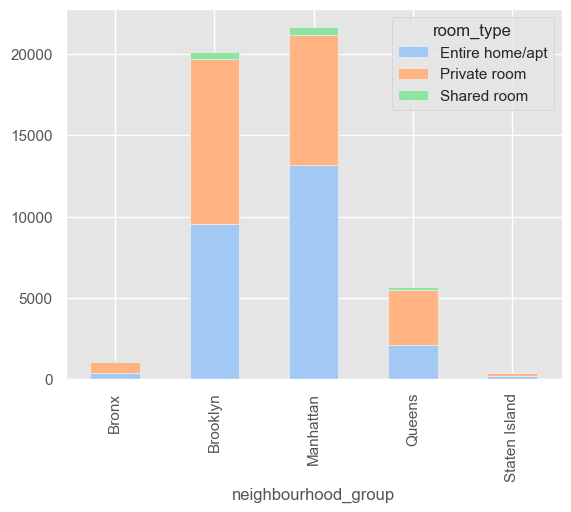

In [18]:
data.groupby(['neighbourhood_group','room_type']).size().unstack().plot(kind = 'bar',stacked = True)

### 9. Room Type Distribution by Area

In [19]:
data['host_name'].value_counts().reset_index().head(1)

,host_name,count
0,Michael,417


> Entire homes dominate across most neighborhood groups, but private rooms are also widely available, especially in budget-friendly areas.

---

###  10. Availability Trends

In [20]:
# Count the number of listings available for more than 180 days
listings_available_more_than_180_days = len(data[data['availability_365'] > 180])

# Calculate the total number of listings
total_listings = len(data)

# Calculate the percentage
percentage_available_more_than_180_days = (listings_available_more_than_180_days / total_listings) * 100
percentage_available_more_than_180_days


29.377236936292057

> A percentage of listings are available for more than 180 days a year, which may indicate:

* Lower booking frequency
* Overpricing
* Less demand

---

### 11. Host with Maximum Listings

In [21]:
max_host_id = data['host_id'].value_counts().idxmax()

# Finding corresponding host name
data[data['host_id'] == max_host_id]['host_name'].iloc[0]


'Sonder (NYC)'

> Certain hosts own a large number of properties, highlighting the presence of commercial operators rather than individual hosts.

---

In [22]:
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

### 12. Neighborhood-wise Top Hosts


In [23]:
# Group the data by 'neighbourhood_group' and 'host_name', and count the occurrences
host_properties_count = data.groupby(['neighbourhood_group', 'host_name']).size()

# Find the index of the maximum count within each neighbourhood group
max_hosts_indices = host_properties_count.groupby(level=0).idxmax()

# Retrieve the host name corresponding to the maximum count indices
max_hosts = host_properties_count.loc[max_hosts_indices].reset_index()

# Rename the count column
max_hosts.rename(columns={0: 'max_properties_count'}, inplace=True)

print(max_hosts)


  neighbourhood_group     host_name  max_properties_count
0               Bronx           Vie                    13
1            Brooklyn       Michael                   159
2           Manhattan  Sonder (NYC)                   327
3              Queens        Kazuya                    79
4       Staten Island         Maria                     9


> In each neighborhood group, a few hosts dominate in terms of property count, indicating localized competition and market control.

---


### 🔹 13. Factors Affecting Price

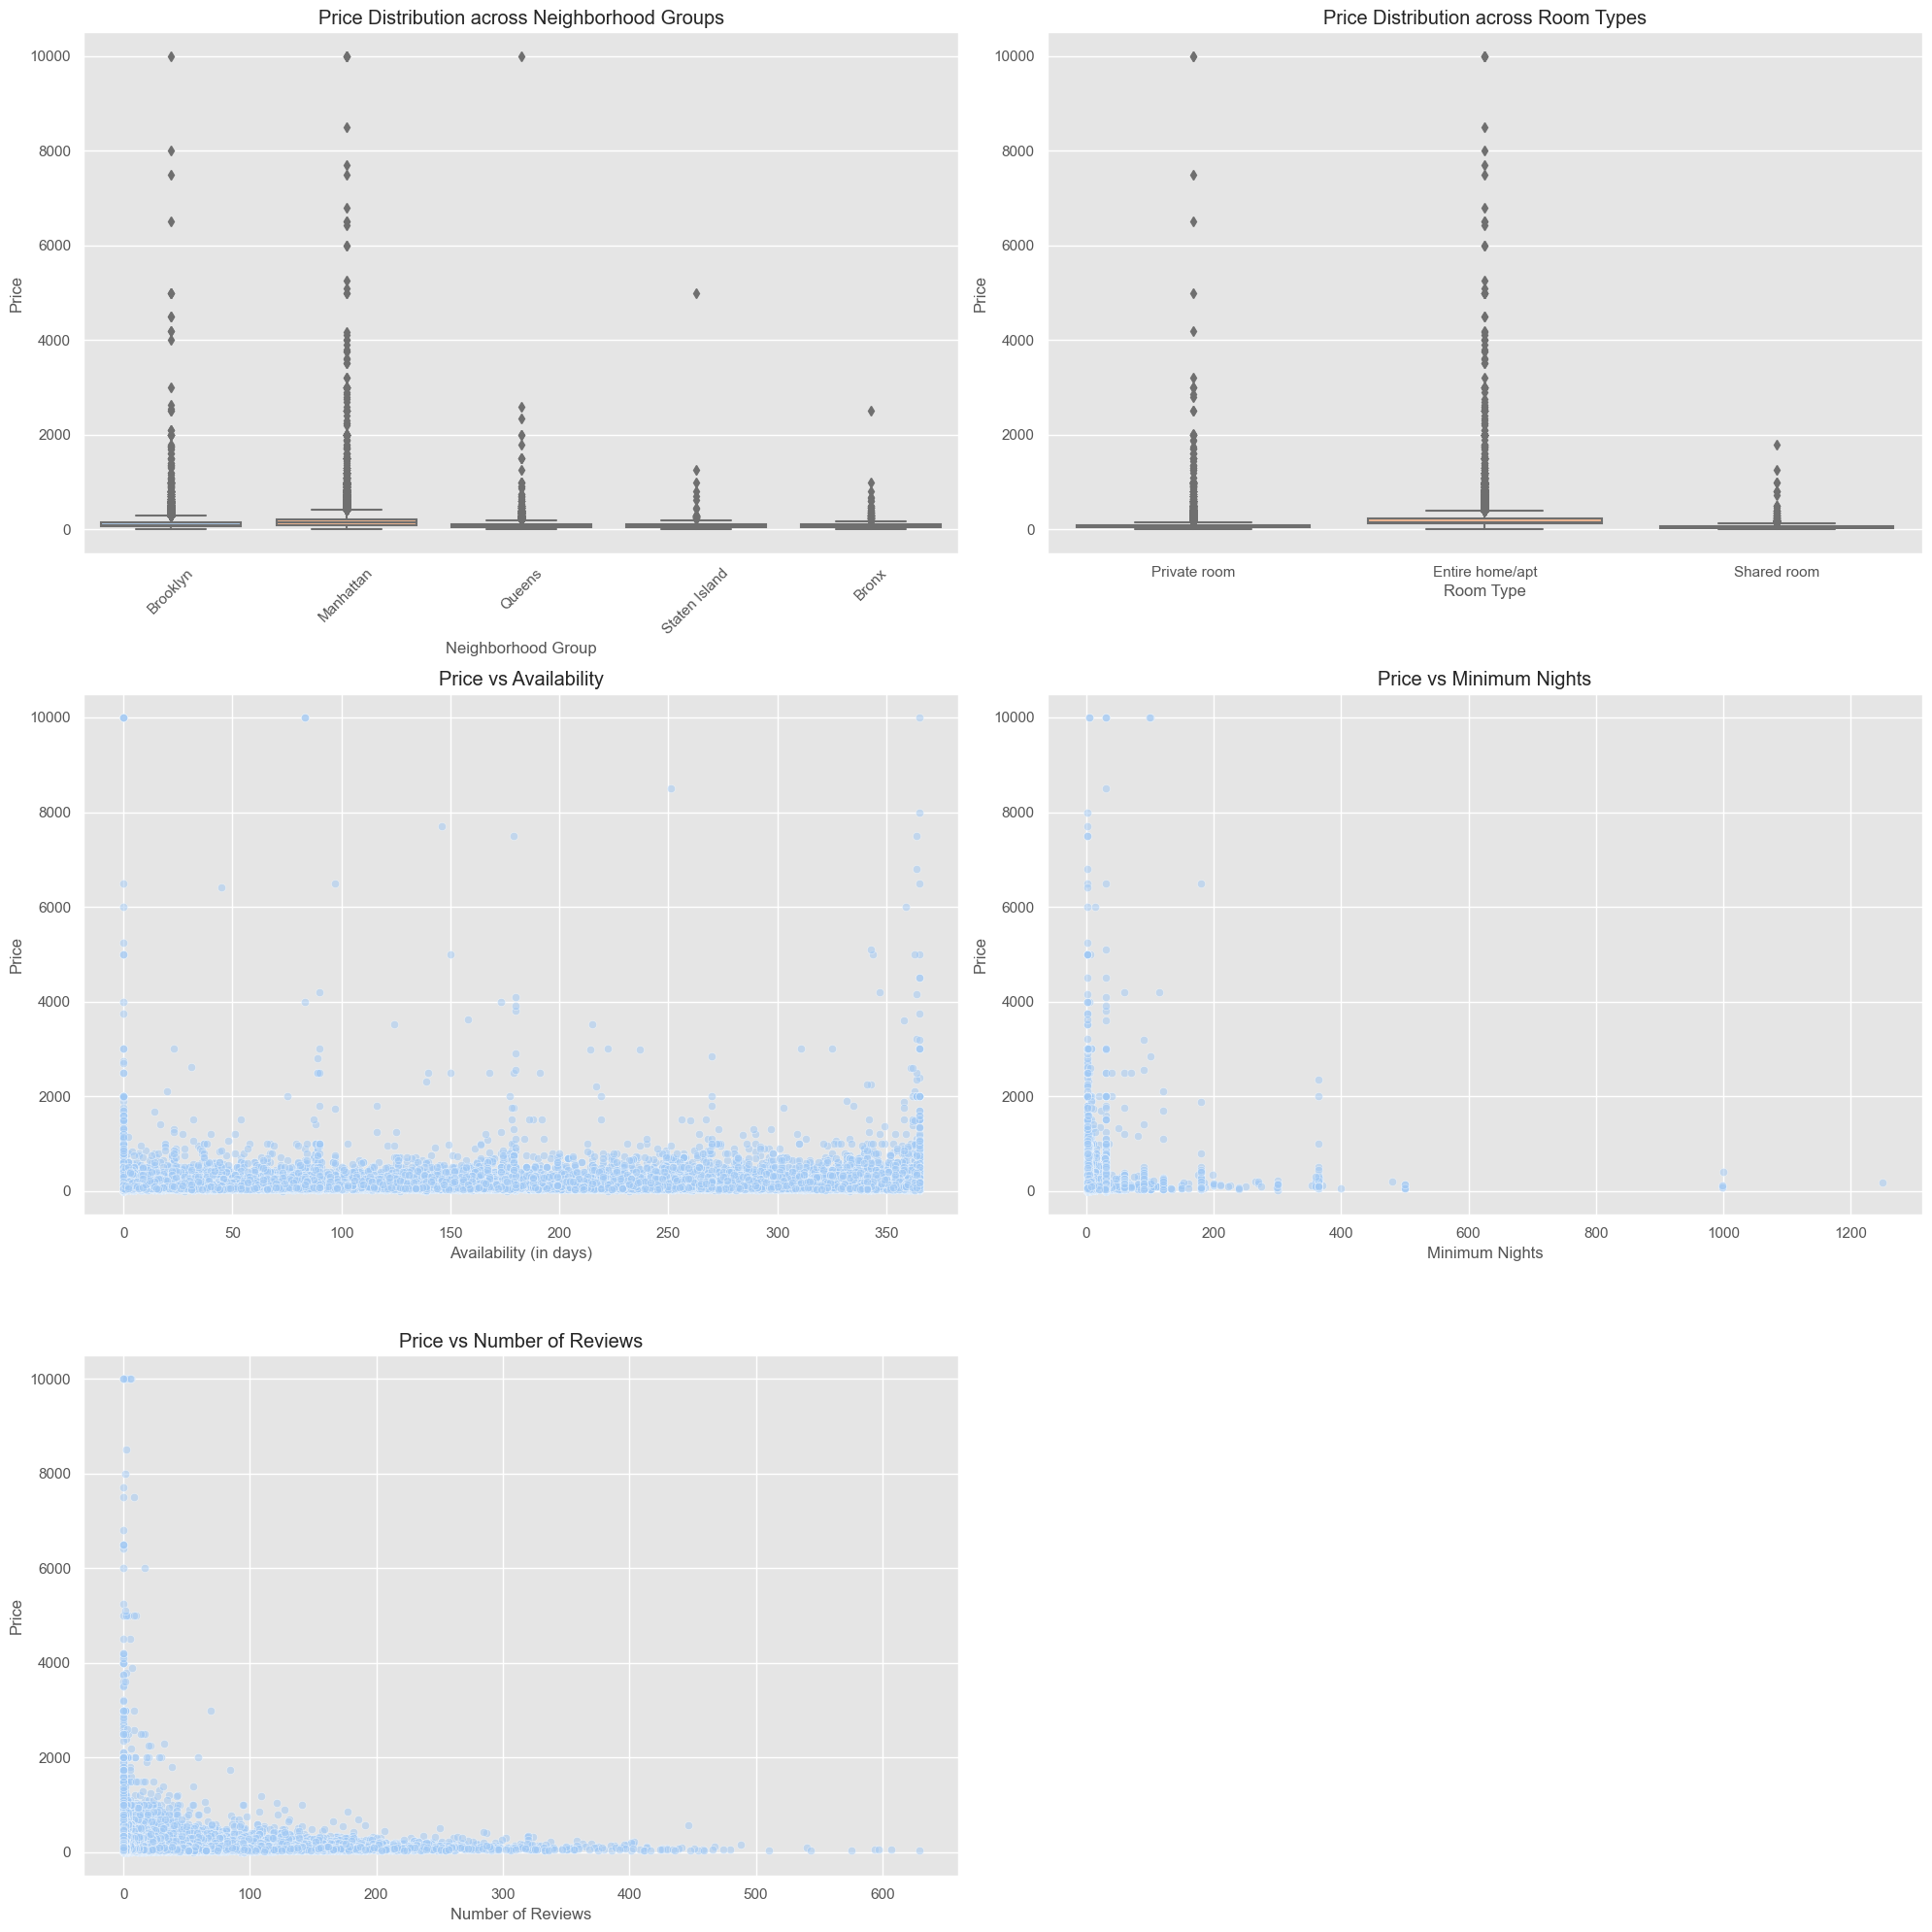

In [24]:
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))

# Relationship between price and neighborhood group
sns.boxplot(data=data, x='neighbourhood_group', y='price', ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution across Neighborhood Groups')
axes[0, 0].set_xlabel('Neighborhood Group')
axes[0, 0].set_ylabel('Price')
axes[0, 0].tick_params(axis='x', rotation=45)

# Relationship between price and room type
sns.boxplot(data=data, x='room_type', y='price', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution across Room Types')
axes[0, 1].set_xlabel('Room Type')
axes[0, 1].set_ylabel('Price')

# Relationship between price and availability
sns.scatterplot(data=data, x='availability_365', y='price', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Price vs Availability')
axes[1, 0].set_xlabel('Availability (in days)')
axes[1, 0].set_ylabel('Price')

# Relationship between price and minimum nights
sns.scatterplot(data=data, x='minimum_nights', y='price', alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Price vs Minimum Nights')
axes[1, 1].set_xlabel('Minimum Nights')
axes[1, 1].set_ylabel('Price')

# Relationship between price and number of reviews
sns.scatterplot(data=data, x='number_of_reviews', y='price', alpha=0.5, ax=axes[2, 0])
axes[2, 0].set_title('Price vs Number of Reviews')
axes[2, 0].set_xlabel('Number of Reviews')
axes[2, 0].set_ylabel('Price')

# Remove the empty subplot
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.show()


> Based on visual analysis:

* Price is higher for entire homes compared to shared rooms
* Listings with low availability often have higher prices
* High minimum nights may be associated with premium listings
* Reviews do not strongly impact pricing

---


### 14. Most Preferred Room Type by Area


In [25]:
# Group the data by 'neighbourhood_group' and 'room_type', and count the occurrences
room_type_counts = data.groupby(['neighbourhood_group', 'room_type']).size()

# Find the index of the maximum count within each neighborhood group
most_preferred_room_type_indices = room_type_counts.groupby(level=0).idxmax()

# Retrieve the room type corresponding to the maximum count indices
most_preferred_room_types = room_type_counts.loc[most_preferred_room_type_indices]

print(most_preferred_room_types)


neighbourhood_group  room_type      
Bronx                Private room         652
Brooklyn             Private room       10132
Manhattan            Entire home/apt    13199
Queens               Private room        3372
Staten Island        Private room         188
dtype: int64


> The most preferred room type across all neighborhood groups is **Entire home/apartment**, showing consistent customer preference for privacy.

---

### 15. Availability by Room Type


In [26]:
 data.groupby('room_type')['availability_365'].sum()

room_type
Entire home/apt    2843783
Private room       2482739
Shared room         187921
Name: availability_365, dtype: int64

> Entire homes contribute the highest total availability, indicating that they dominate the platform supply.

---


### 16. Most Reviewed Property

In [27]:
# Find the index of the row with the maximum number of reviews
max_reviews_index = data['number_of_reviews'].idxmax()

# Get the details of the property with the maximum number of reviews
property_with_max_reviews = data.loc[max_reviews_index]

property_with_max_reviews


id                                                9145202
name                              Room near JFK Queen Bed
host_id                                          47621202
host_name                                            Dona
neighbourhood_group                                Queens
neighbourhood                                     Jamaica
latitude                                          40.6673
longitude                                       -73.76831
room_type                                    Private room
price                                                  47
minimum_nights                                          1
number_of_reviews                                     629
last_review                                    2019-07-05
reviews_per_month                                   14.58
calculated_host_listings_count                          2
availability_365                                      333
Name: 11759, dtype: object

> The property with the highest number of reviews indicates high customer engagement and popularity, likely due to competitive pricing and good service.

---



Business Recommendations
---

### 1. Pricing Strategy Optimization

> Hosts in high-demand areas like Manhattan can adopt dynamic pricing strategies to maximize revenue, especially during peak seasons. Competitive pricing should be considered in lower-demand areas to attract more bookings.

---

### 2. Focus on Entire Homes

> Since entire homes/apartments are the most preferred room type, hosts should prioritize offering full-property listings to increase occupancy and revenue potential.

---

### 3. Improve Listing Visibility

> Listings with zero or low reviews should focus on:

* Better descriptions
* Competitive pricing
* Discounts for initial bookings
  to improve visibility and attract customers.

---

### 4. Optimize Availability

> Listings with high availability but low bookings may indicate overpricing or low demand. Hosts should adjust pricing or improve listing quality to increase occupancy rates.

---

### 5. Target High-Performing Areas

> New hosts should consider investing in neighborhoods with higher demand and better pricing potential to maximize returns.

---

### 6. Leverage Reviews for Growth

> Since reviews influence trust, hosts should focus on delivering better customer experiences to increase positive reviews and improve booking rates.

---

### 7. Professional Hosting Opportunity

> Hosts with multiple listings indicate a scalable business model. New hosts can explore property management strategies to expand their listings portfolio.

---



### Limitations

> This dataset is from 2019 and is used for analytical learning purposes. Market trends may have evolved significantly after the COVID-19 pandemic, which impacted the travel and hospitality industry. However, the analytical approach and insights derived remain relevant for understanding general pricing patterns and customer behavior.

### Conclusion

> This project analyzed the Airbnb NYC 2019 dataset to uncover key insights related to pricing, customer preferences, and host performance. The analysis revealed that location plays a major role in pricing, with Manhattan leading as the most premium market. Entire homes emerged as the most preferred room type, indicating strong demand for privacy among customers.

> Additionally, factors such as availability, number of reviews, and minimum stay requirements influence listing performance. The presence of hosts with multiple listings highlights opportunities for scalable property management. Overall, the project demonstrates how data analysis can help optimize pricing strategies and improve decision-making in the short-term rental market.